In [1]:
!pip -q install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.7/11.7 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.8/3.8 MB 73.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 49.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.8/148.8 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 228.4/228.4 kB 15.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 148.7/148.7 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import mlflow
import mlflow.sklearn

np.random.seed(42)

samples = 500
engine_size = np.random.uniform(1.0,5.0,samples)
horsepower = 65 + engine_size*42 + np.random.normal(0,15,samples)
vehicle_age = np.random.uniform(0,15,samples)
price = 25000 + horsepower*75 - vehicle_age*1350 + np.random.normal(0,1400,samples)

vehicle_df = pd.DataFrame({
    "engine_size_L": engine_size,
    "horsepower": horsepower,
    "age_years": vehicle_age,
    "price": price
})

X = vehicle_df.drop(columns="price")
y = vehicle_df["price"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42)
}

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("vehicle_price_pipeline")

results = {}
logged_runs = {}

for model_name, model in models.items():
    with mlflow.start_run(run_name=model_name) as run:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

        mae = mean_absolute_error(y_test, predictions)
        rmse = mean_squared_error(y_test, predictions) ** 0.5
        r2 = r2_score(y_test, predictions)

        mlflow.log_param("model_type", model_name)
        mlflow.log_metric("MAE", mae)
        mlflow.log_metric("RMSE", rmse)
        mlflow.log_metric("R2", r2)

        # Conditionally log trusted types only for RandomForestRegressor
        if model_name == "Random Forest":
            mlflow.sklearn.log_model(model, "model", skops_trusted_types=["sklearn.tree._tree.Tree"])
        else:
            mlflow.sklearn.log_model(model, "model")

        results[model_name] = {"MAE": mae, "RMSE": rmse, "R2": r2}
        logged_runs[model_name] = run.info.run_id

results_df = pd.DataFrame(results).T
display(results_df.round(3))
print("Run IDs:", logged_runs)

2026/09/25 16:04:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/09/25 16:04:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


,MAE,RMSE,R2
Linear Regression,1339.852,1650.506,0.949
Random Forest,1480.120,1901.438,0.933


Run IDs: {'Linear Regression': '30d087981c1443dfb4afddab969bf7b5', 'Random Forest': '2e417c9dbc0f4d5a8ee8d66ebd786978'}


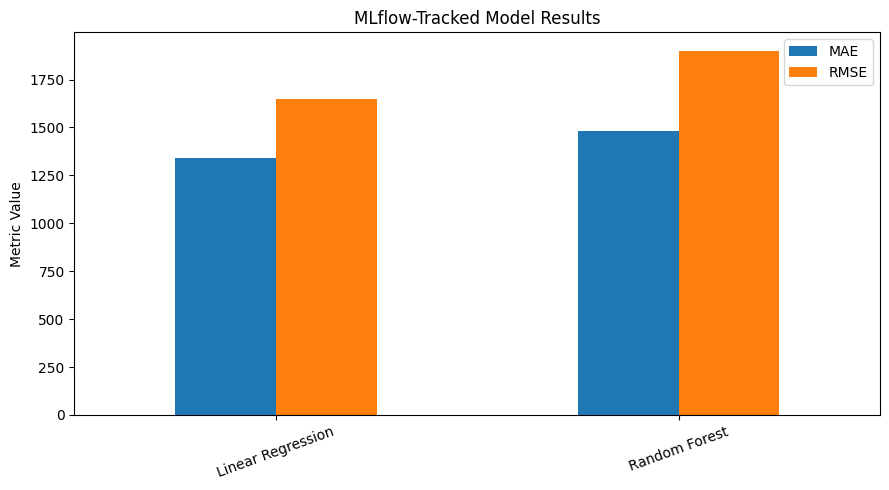

In [4]:
plt.figure(figsize=(9,5))
results_df[["MAE","RMSE"]].plot(kind="bar", ax=plt.gca())
plt.title("MLflow-Tracked Model Results")
plt.ylabel("Metric Value")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [5]:
dockerfile = '''FROM python:3.11-slim
WORKDIR /app
COPY . /app
RUN pip install --no-cache-dir pandas numpy scikit-learn mlflow
CMD ["python", "app.py"]
'''
with open("Dockerfile", "w") as f:
    f.write(dockerfile)

app_code = '''print("Vehicle price ML deployment container started.")\n'''
with open("app.py", "w") as f:
    f.write(app_code)

print("Dockerfile generated successfully.")

Dockerfile generated successfully.


In [6]:
import os
os.makedirs(".github/workflows", exist_ok=True)

workflow = '''name: ML CI/CD

on:
  push:
    branches: ["main"]
  pull_request:
    branches: ["main"]

jobs:
  train-and-build:
    runs-on: ubuntu-latest
    steps:
      - uses: actions/checkout@v4

      - uses: actions/setup-python@v5
        with:
          python-version: "3.11"

      - name: Install dependencies
        run: pip install numpy pandas scikit-learn mlflow

      - name: Run pipeline
        run: python app.py

      - name: Build Docker image
        run: docker build -t vehicle-price-mlops .
'''

with open(".github/workflows/github_actions.yml", "w") as f:
    f.write(workflow)

print("Generated:")
print("1. mlflow.db")
print("2. Dockerfile")
print("3. github_actions.yml")

Generated:
1. mlflow.db
2. Dockerfile
3. github_actions.yml
